# House Price Prediction using Machine Learning


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/House_Prediction.csv")

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
df.shape

(4600, 18)

In [5]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [6]:
df.dtypes

date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [8]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [9]:
df.isnull().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.nunique()

date               70
price            1741
bedrooms           10
bathrooms          26
sqft_living       566
sqft_lot         3113
floors              6
waterfront          2
view                5
condition           5
sqft_above        511
sqft_basement     207
yr_built          115
yr_renovated       60
street           4525
city               44
statezip           77
country             1
dtype: int64

In [12]:
df.corr(numeric_only=True)

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774
bedrooms,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082
bathrooms,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886
sqft_living,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817
sqft_lot,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730
floors,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996
waterfront,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625
view,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967
condition,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818
sqft_above,0.367570,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426


### Data Visualizations   


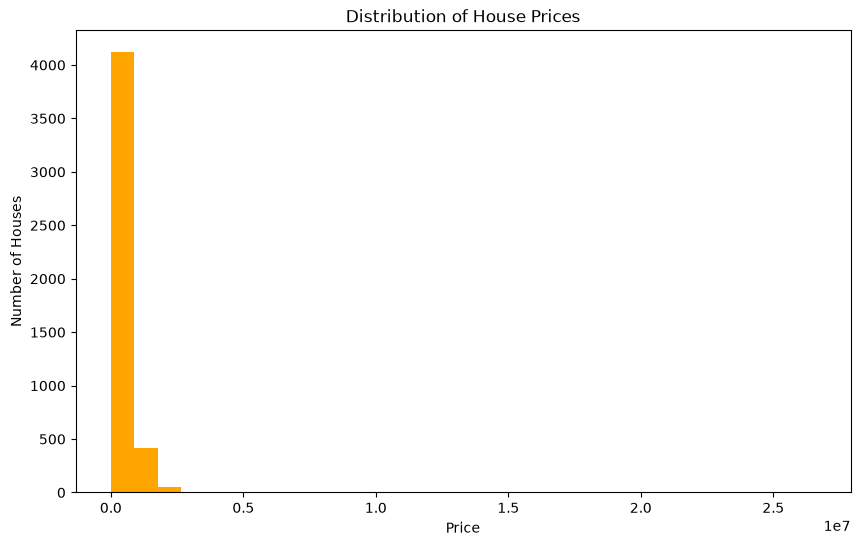

In [13]:
plt.figure(figsize=(10,6))

plt.hist(df["price"], bins=30,color="orange")
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Number of Houses")

plt.show()

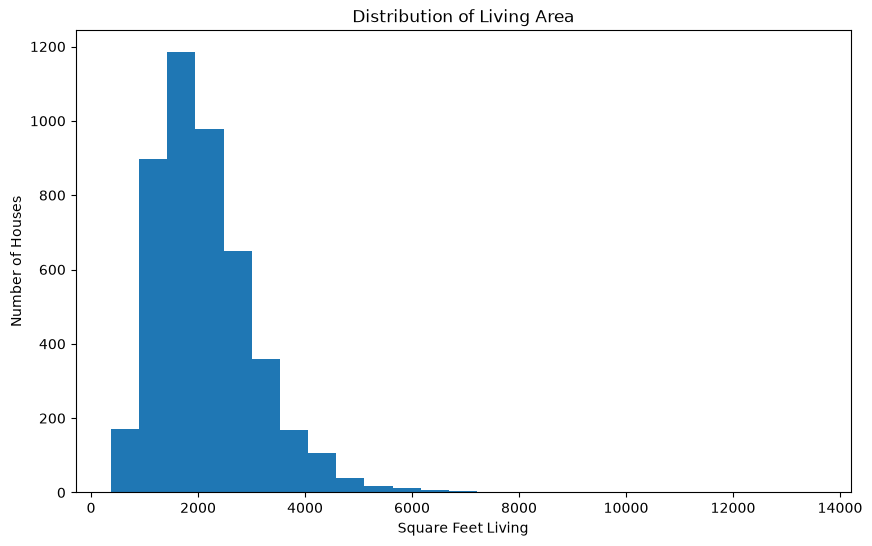

In [14]:
plt.figure(figsize=(10,6))

plt.hist(df["sqft_living"], bins=25)
plt.title("Distribution of Living Area")
plt.xlabel("Square Feet Living")
plt.ylabel("Number of Houses")

plt.show()

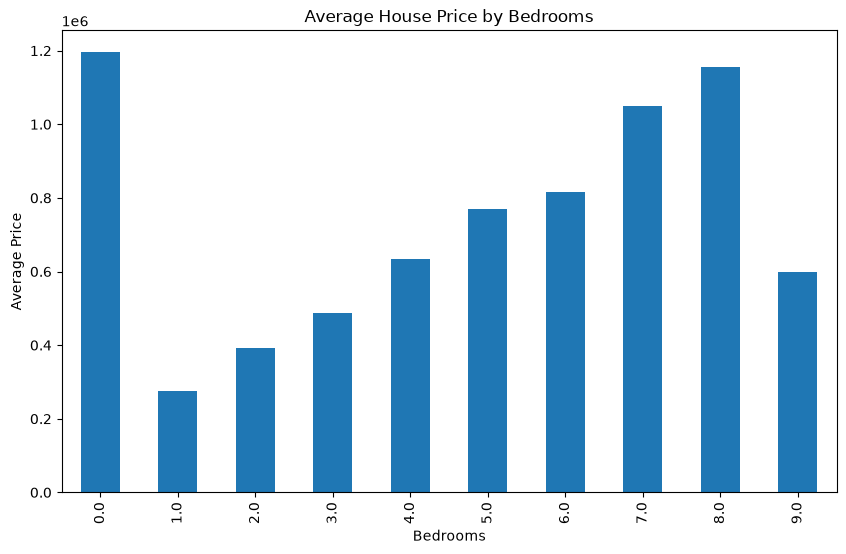

In [15]:
plt.figure(figsize=(10,6))

average_price = df.groupby("bedrooms")["price"].mean()
average_price.plot(kind="bar")
plt.title("Average House Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")

plt.show()

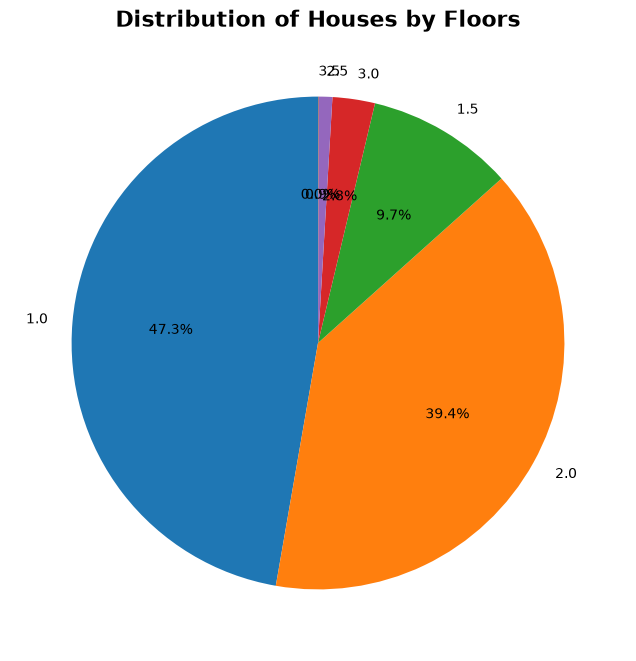

In [16]:
floor_count = df["floors"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    floor_count,
    labels=floor_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Houses by Floors", fontsize=16, fontweight="bold")

plt.show()

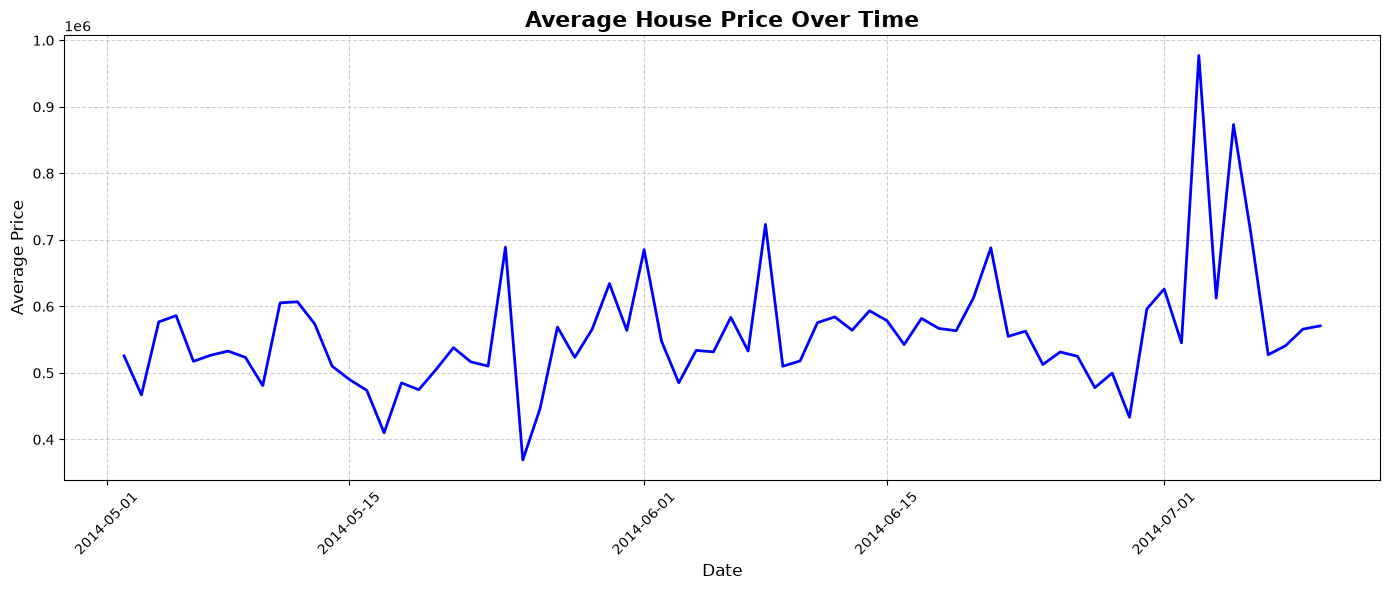

In [17]:
df["date"] = pd.to_datetime(df["date"])

average_price = df.groupby("date")["price"].mean()
plt.figure(figsize=(14,6))
plt.plot(
    average_price.index,
    average_price.values,
    color="blue",
    linewidth=2
)
plt.title("Average House Price Over Time", fontsize=16, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Average Price", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.6)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

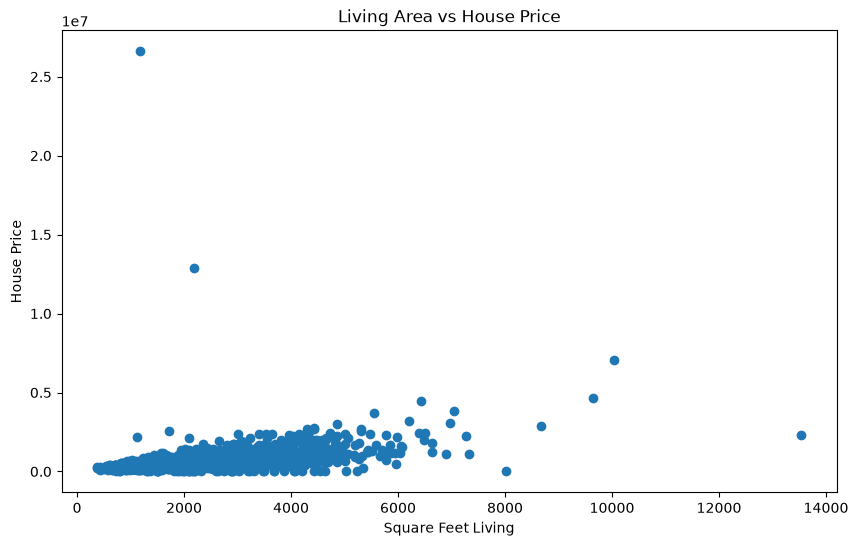

In [18]:
plt.figure(figsize=(10,6))

plt.scatter(df["sqft_living"], df["price"])
plt.title("Living Area vs House Price")
plt.xlabel("Square Feet Living")
plt.ylabel("House Price")

plt.show()

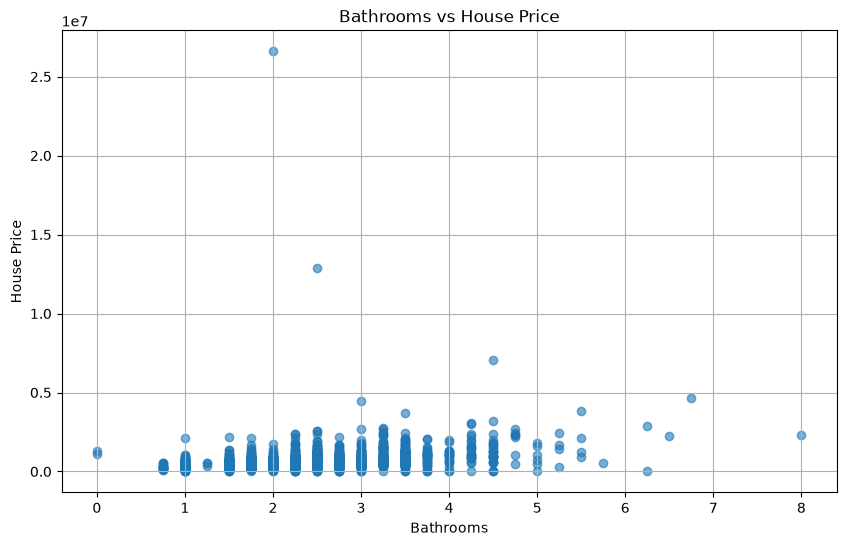

In [19]:
plt.figure(figsize=(10,6))

plt.scatter(df["bathrooms"], df["price"], alpha=0.6)

plt.title("Bathrooms vs House Price")
plt.xlabel("Bathrooms")
plt.ylabel("House Price")

plt.grid(True)
plt.show()

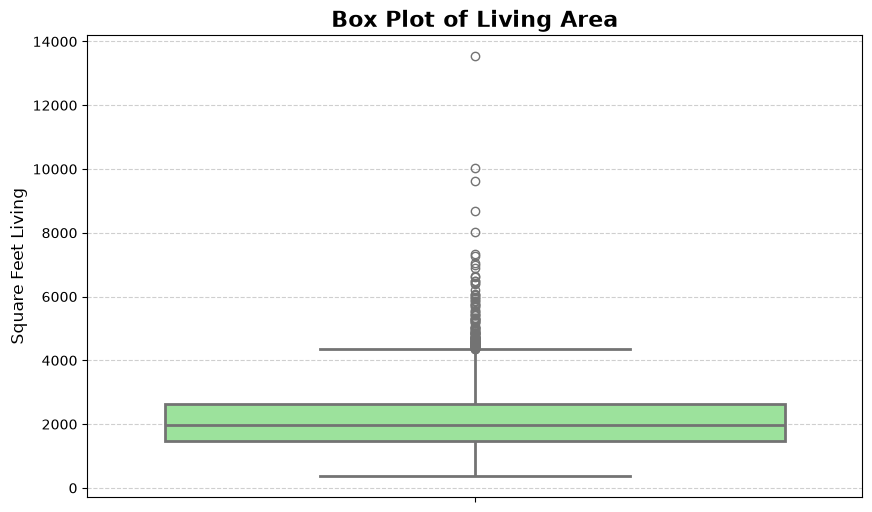

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y=df["sqft_living"],
    color="lightgreen",
    linewidth=2
)

plt.title("Box Plot of Living Area", fontsize=16, fontweight="bold")
plt.ylabel("Square Feet Living", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

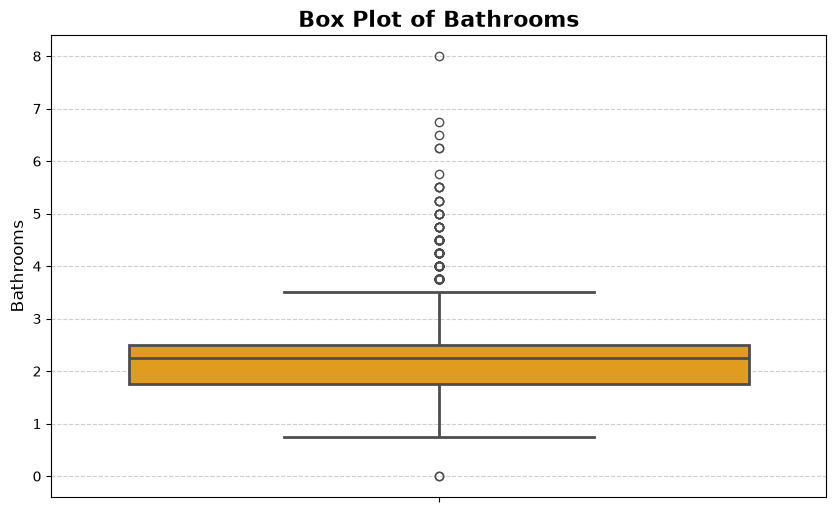

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
    y=df["bathrooms"],
    color="orange",
    linewidth=2
)

plt.title("Box Plot of Bathrooms", fontsize=16, fontweight="bold")
plt.ylabel("Bathrooms", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

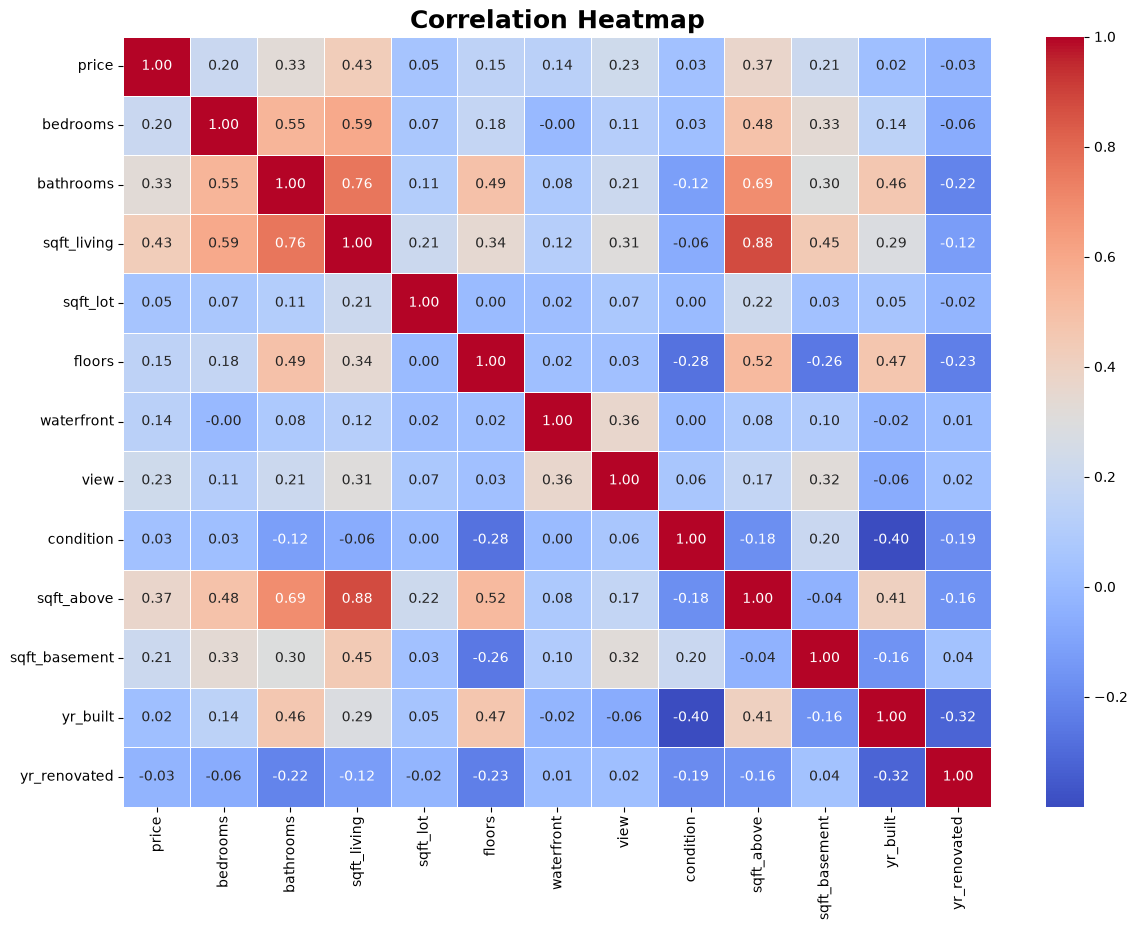

In [22]:
plt.figure(figsize=(14,10))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18, fontweight="bold")

plt.show()

### Remove Houses with Price = 0

In [23]:
df = df[df["price"] > 0]

### Feature Selection

In [24]:
X = df.drop(columns=["date", "price", "street", "country"])
y = df["price"]

### Handling Categorical Data

In [25]:
print(X.dtypes)

bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
city                 str
statezip             str
dtype: object


In [26]:
X = pd.get_dummies(X, drop_first=True)

In [27]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,...,statezip_WA 98155,statezip_WA 98166,statezip_WA 98168,statezip_WA 98177,statezip_WA 98178,statezip_WA 98188,statezip_WA 98198,statezip_WA 98199,statezip_WA 98288,statezip_WA 98354
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,...,False,False,False,False,False,False,False,False,False,False
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,...,False,False,False,False,False,False,False,False,False,False
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,...,False,False,False,False,False,False,False,False,False,False
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,...,False,False,False,False,False,False,False,False,False,False
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,...,False,False,False,False,False,False,False,False,False,False


In [28]:
print("Shape after encoding:", X.shape)

Shape after encoding: (4551, 131)


### Train-Test-Split

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (3640, 131)
X_test : (911, 131)
y_train: (3640,)
y_test : (911,)


## Linear Regression

### Create model

In [30]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

### Train the model

In [31]:
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [32]:
pd.options.display.float_format = '{:,.2f}'.format

### Prediction

In [33]:
predictions = model.predict(X_test)

predictions_df = pd.DataFrame(predictions, columns=["Predicted Price"])
print(predictions_df.head(10))

   Predicted Price
0     1,309,065.08
1       564,051.73
2       588,668.68
3       217,499.33
4       647,592.65
5       395,050.73
6       305,456.91
7       281,581.02
8       439,017.45
9       849,379.87


In [34]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

results.head(10)


,Actual Price,Predicted Price
0,"1,225,000.00","1,309,065.08"
1,"496,752.00","564,051.73"
2,"612,500.00","588,668.68"
3,"265,000.00","217,499.33"
4,"615,000.00","647,592.65"
5,"432,000.00","395,050.73"
6,"305,000.00","305,456.91"
7,"405,000.00","281,581.02"
8,"349,000.00","439,017.45"
9,"839,000.00","849,379.87"


### Model Evaluation

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [36]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 119164.57451487507
Mean Squared Error (MSE): 45411833071.12749
Root Mean Squared Error (RMSE): 213100.52339477604
R² Score: 0.6947522093553522


### Prediction of a New House

In [37]:
feature_names = X.columns
print(feature_names)


Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       ...
       'statezip_WA 98155', 'statezip_WA 98166', 'statezip_WA 98168',
       'statezip_WA 98177', 'statezip_WA 98178', 'statezip_WA 98188',
       'statezip_WA 98198', 'statezip_WA 98199', 'statezip_WA 98288',
       'statezip_WA 98354'],
      dtype='str', length=131)


### Save the Model

In [38]:
import joblib

joblib.dump(model, "house_price_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [39]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df.head(10)

,Feature,Coefficient
0,bedrooms,"-30,737.73"
1,bathrooms,"34,782.15"
2,sqft_living,126.46
3,sqft_lot,0.16
4,floors,"-80,247.27"
5,waterfront,"577,664.44"
6,view,"60,103.71"
7,condition,"36,819.87"
8,sqft_above,129.38
9,sqft_basement,-2.91


## Decision Tree 

In [40]:
from sklearn.tree import DecisionTreeRegressor

### Create Model

In [41]:
dt_model = DecisionTreeRegressor(random_state=42)

### Train the model

In [42]:
dt_model.fit(X_train, y_train)

print("Decision Tree Model trained successfully!")

Decision Tree Model trained successfully!


### Predict

In [43]:
dt_predictions = dt_model.predict(X_test)

### Evaluate

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Results")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R² Score:", dt_r2)

Decision Tree Results
MAE : 174116.64264049946
MSE : 854838518694.0972
RMSE: 924574.7772322675
R² Score: -4.746025904319173


## Random Forest

In [45]:
from sklearn.ensemble import RandomForestRegressor

### Create Model

In [46]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

### Train the model

In [47]:
rf_model.fit(X_train, y_train)

print("Random Forest Model trained successfully!")

Random Forest Model trained successfully!


### Predict

In [48]:
rf_predictions = rf_model.predict(X_test)

### Evaluate

In [49]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
MAE : 127356.40260896567
MSE : 250209604920.445
RMSE: 500209.56100463035
R² Score: -0.6818508290649756


### Feature Importance

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
2,sqft_living,0.45
10,yr_built,0.13
3,sqft_lot,0.12
8,sqft_above,0.11
1,bathrooms,0.02
128,statezip_WA 98199,0.02
57,statezip_WA 98004,0.01
73,statezip_WA 98031,0.01
7,condition,0.01
46,city_Seattle,0.01


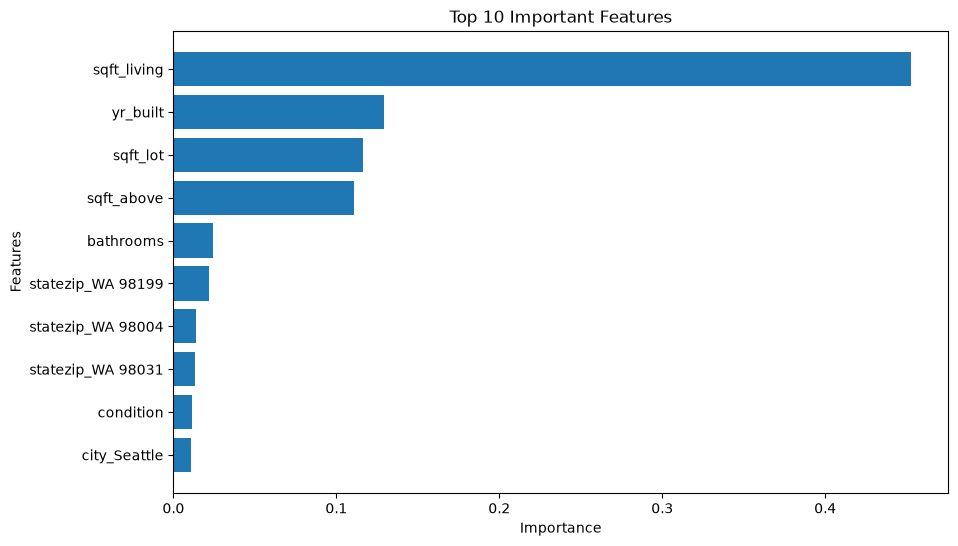

In [51]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(top10["Feature"], top10["Importance"])

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

## KNN

In [52]:
from sklearn.neighbors import KNeighborsRegressor

### Create Model

In [53]:
knn_model = KNeighborsRegressor(n_neighbors=5)

### Train the model

In [54]:
knn_model.fit(X_train, y_train)

print("KNN Model trained successfully!")

KNN Model trained successfully!


### Predict

In [55]:
knn_predictions = knn_model.predict(X_test)

### Evaluate

In [56]:
knn_mae = mean_absolute_error(y_test, knn_predictions)
knn_mse = mean_squared_error(y_test, knn_predictions)
knn_rmse = np.sqrt(knn_mse)
knn_r2 = r2_score(y_test, knn_predictions)

print("KNN Results")
print("MAE :", knn_mae)
print("MSE :", knn_mse)
print("RMSE:", knn_rmse)
print("R² Score:", knn_r2)

KNN Results
MAE : 187213.39044748433
MSE : 101590918286.8427
RMSE: 318733.3027577173
R² Score: 0.3171294515231565


## Support Vector Regressor

In [57]:
from sklearn.svm import SVR

### Create Model

In [58]:
svr_model = SVR(kernel="rbf")

### Train The Model

In [59]:
svr_model.fit(X_train, y_train)

print("SVR Model trained successfully!")

SVR Model trained successfully!


### Predict

In [60]:
svr_predictions = svr_model.predict(X_test)

### Evaluate

In [61]:
svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("SVR Results")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R² Score:", svr_r2)

SVR Results
MAE : 232646.7143681321
MSE : 157259897621.60815
RMSE: 396560.0807212044
R² Score: -0.057064493098375024


### Comparison

In [62]:
comparison = pd.DataFrame({
    "Algorithm": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVR"
    ],
    "MAE": [mae, dt_mae, rf_mae, knn_mae, svr_mae],
    "RMSE": [rmse, dt_rmse, rf_rmse, knn_rmse, svr_rmse],
    "R² Score": [r2, dt_r2, rf_r2, knn_r2, svr_r2]
})

display(comparison)

,Algorithm,MAE,RMSE,R² Score
0,Linear Regression,"119,164.57","213,100.52",0.69
1,Decision Tree,"174,116.64","924,574.78",-4.75
2,Random Forest,"127,356.40","500,209.56",-0.68
3,KNN,"187,213.39","318,733.30",0.32
4,SVR,"232,646.71","396,560.08",-0.06


## Best Model Selection

In [63]:
best_model = comparison.loc[comparison["R² Score"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Algorithm    Linear Regression
MAE                 119,164.57
RMSE                213,100.52
R² Score                  0.69
Name: 0, dtype: object


### Actual vs Predicted Plot

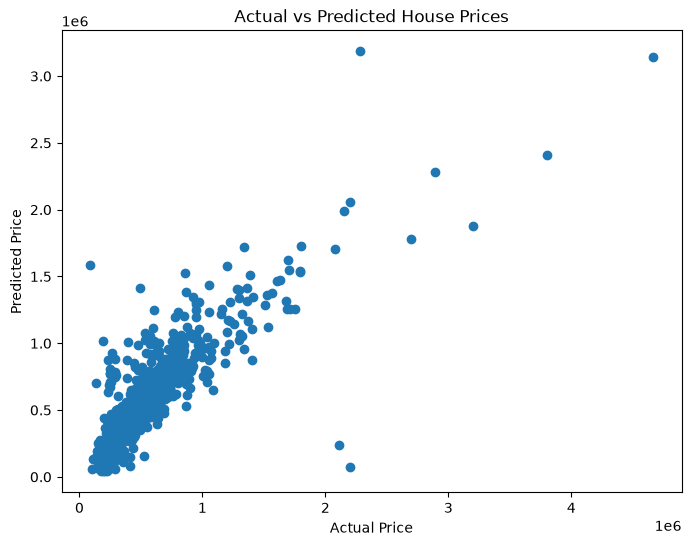

In [64]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [65]:
import joblib

joblib.dump(model, "Best_House_Price_Model.pkl")

print("Best Model Saved Successfully!")

Best Model Saved Successfully!


## Predict House Price for New Data

In [66]:
new_house = pd.DataFrame(0, index=[0], columns=X.columns)

In [67]:
new_house["bedrooms"] = 3
new_house["bathrooms"] = 2
new_house["sqft_living"] = 1800
new_house["sqft_lot"] = 5000
new_house["floors"] = 2
new_house["waterfront"] = 0
new_house["view"] = 1
new_house["condition"] = 3
new_house["sqft_above"] = 1500
new_house["sqft_basement"] = 300
new_house["yr_built"] = 2005
new_house["yr_renovated"] = 0

In [68]:
new_house["city_Seattle"] = 1

In [69]:
new_house["statezip_WA 98103"] = 1

In [70]:
predicted_price = model.predict(new_house)

print("Predicted House Price: ₹{:,.2f}".format(predicted_price[0]))

Predicted House Price: ₹618,203.82
